In [2]:
import numpy as np

np.random.seed(42)
m = 100
X = np.empty((m, 3))
X[:, 0] = np.random.rand(m) * 2 - 1
X[:, 1] = np.random.rand(m) * 2 - 1
X[:, 2] = 2 * X[:, 0] + 3 * X[:, 1] + np.random.randn(m) * 0.1

X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)

c1 = Vt.T[:, 0]
c2 = Vt.T[:, 1]

In [3]:
print("First Principal Component (c1):", c1)
print("Second Principal Component (c2):", c2)

First Principal Component (c1): [0.14507956 0.22218185 0.964151  ]
Second Principal Component (c2): [-8.37244244e-01  5.46829110e-01 -2.95378654e-05]


In [4]:
W2 = Vt.T[:, :2]

X2D = X_centered.dot(W2)

print("Original dataset shape:", X.shape)
print("Reduced dataset shape:", X2D.shape)
print("\nFirst 3 rows of the new 2D dataset:\n", X2D[:3])

Original dataset shape: (100, 3)
Reduced dataset shape: (100, 2)

First 3 rows of the new 2D dataset:
 [[-3.37792691 -0.34983956]
 [ 2.86787958 -0.6531719 ]
 [-0.03940201 -0.6390619 ]]


In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X2D_sklearn = pca.fit_transform(X)

print("Reduced dataset shape (Scikit-Learn):", X2D_sklearn.shape)

c1_sklearn = pca.components_[0]
c2_sklearn = pca.components_[1]

print("\nFirst PC (Scikit-Learn):", c1_sklearn)

Reduced dataset shape (Scikit-Learn): (100, 2)

First PC (Scikit-Learn): [0.14507956 0.22218185 0.964151  ]


In [6]:
ratios = pca.explained_variance_ratio_

print(f"Variance held by PC1: {ratios[0]:.4f} ({ratios[0]*100:.2f}%)")
print(f"Variance held by PC2: {ratios[1]:.4f} ({ratios[1]*100:.2f}%)")
print(f"Total information preserved: {ratios.sum()*100:.2f}%")

Variance held by PC1: 0.9293 (92.93%)
Variance held by PC2: 0.0706 (7.06%)
Total information preserved: 99.99%


Original dimensions: 10
Dimensions kept for 95% variance: 10


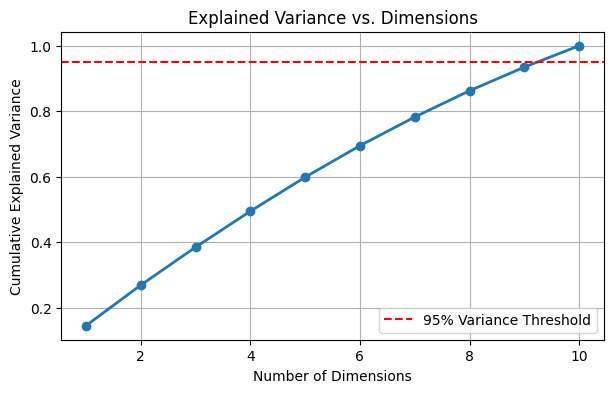

In [8]:
import matplotlib.pyplot as plt

np.random.seed(42)
X_high_dim = np.random.randn(200, 10)

pca_auto = PCA(n_components=0.95)
X_reduced_auto = pca_auto.fit_transform(X_high_dim)

print(f"Original dimensions: {X_high_dim.shape[1]}")
print(f"Dimensions kept for 95% variance: {pca_auto.n_components_}")

pca_full = PCA()
pca_full.fit(X_high_dim)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(cumsum) + 1), cumsum, marker='o', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.xlabel("Number of Dimensions")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs. Dimensions")
plt.legend()
plt.grid(True)
plt.show()